## Universal Approximation Theorem 
The Universal Approximation Theorem is a pivotal result in neural network theory, proving that feedforward neural networks can approximate any continuous function under certain conditions. This theorem provides a mathematical foundation for why neural networks are capable of solving complex problems across various domains like image recognition, natural language processing, and more.

### How Neural Networks Approximate Functions?
Neural networks approximate functions by adjusting the weights and biases of their neurons. When a neural network is trained, it iteratively adjusts these parameters to minimize the error between its predictions and the actual outputs.

### the core idea :
the hidden layers can capture increasingly complex patterns in the data. When enough neurons are used, the network can learn subtle nuances of the target function

### Step1: architecture of the universal approximation theorem 
The Universal Approximation Theorem focuses on a single hidden layer neural network consists of an input layer, one hidden layer, and an output layer

    -Input Layer: Accepts input data.

    -Hidden Layers: Processes the input through weighted connections and activation functions.
    
    -Output Layer: Produces the final result or prediction.


In [16]:
import numpy as np 
class SingleHiddenLayerNN:
    def __init__(self, input_size, hidden_size, output_size):
        self.input_size = input_size
        self.hidden_size = hidden_size
        self.output_size = output_size
        
        # Initialize weights and biases
        self.W1 = np.random.rand(input_size, hidden_size) * 0.01
        self.b1 = np.zeros((1, hidden_size))
        self.W2 = np.random.rand(hidden_size, output_size) * 0.01
        self.b2 = np.zeros((1, output_size))
    
    def forward(self, X):
        # Forward pass
        self.z1 = np.dot(X, self.W1) + self.b1
        self.a1 = self.sigmoid(self.z1)
        self.z2 = np.dot(self.a1, self.W2) + self.b2
        self.a2 = self.sigmoid(self.z2)
        return self.a2
    def sigmoid(self,x):
        return 1 / (1 + np.exp(-x))

# Example usage
nn = SingleHiddenLayerNN(input_size=2, hidden_size=5, output_size=1)
X = np.array([[1, 2]])
output = nn.forward(X)
print(f"Output: {output}")

Output: [[0.50337703]]


### step3: the activation function 
A crucial aspect of the Universal Approximation Theorem is the requirement for non-linearity in the neural network, introduced via  **Activation functions**  enabling it to learn complex patterns. Common activation functions include sigmoid, tanh, and ReLU.

## Mathematical Intuition Behind the Universal Approximation Theorem

The Universal Approximation Theorem can be understood through a constructive perspective: it shows *how* a neural network can be built to approximate any continuous function.

---

### Step 1: Approximating with Step Functions

Any continuous function \( f(x) \) can be approximated by a **step function** (a piecewise constant function).

The idea is simple:
- Break the input space into small intervals
- Assign a constant value on each interval

By making these intervals sufficiently small, the step function becomes a good approximation of \( f(x) \).

---

### Step 2: Neural Networks Approximate Step Functions

A feedforward neural network with a non-linear activation function \( \sigma \) can replicate step-like behavior.

By carefully choosing weights and biases, each neuron can act like a small “bump” or localized region of activation.

The network output can be written as:

\[
\hat{f}(x) = \sum_{i=1}^{M} c_i \cdot \sigma(w_i^T x + b_i)
\]

Where:
- \( \sigma(w_i^T x + b_i) \) creates a localized response
- \( c_i \) controls the contribution of each neuron
- The sum combines these contributions to form the approximation

---

### Step 3: Improving the Approximation

The quality of the approximation depends on the number of neurons \( M \):

- Small \( M \) → rough approximation  
- Large \( M \) → more precise approximation  

As \( M \to \infty \), the network can approximate \( f(x) \) as closely as desired:

\[
|f(x) - \hat{f}(x)| < \epsilon
\]

for any small \( \epsilon > 0 \), over a compact domain.

---

### Conclusion

This shows that a neural network with:
- a non-linear activation function
- and enough neurons

can approximate any continuous function to arbitrary precision.

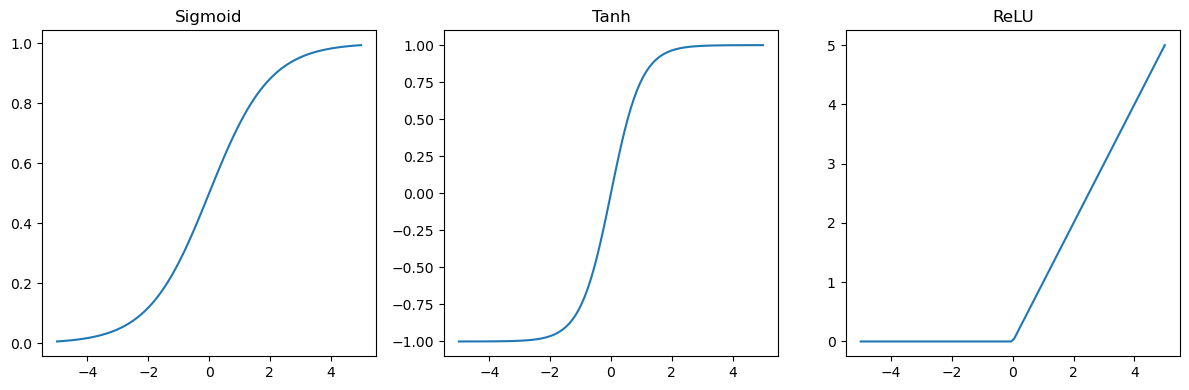

In [7]:
import numpy as np
import matplotlib.pyplot as plt

def sigmoid(x):
    return 1 / (1 + np.exp(-x))

def tanh(x):
    return np.tanh(x)

def relu(x):
    return np.maximum(0, x)

x = np.linspace(-5, 5, 100)

plt.figure(figsize=(12, 4))
plt.subplot(131)
plt.plot(x, sigmoid(x))
plt.title('Sigmoid')
plt.subplot(132)
plt.plot(x, tanh(x))
plt.title('Tanh')
plt.subplot(133)
plt.plot(x, relu(x))
plt.title('ReLU')
plt.tight_layout()
plt.show()

### step 4: Function Approximation

The Universal Approximation Theorem states that neural networks can approximate a wide range of functions. Let's demonstrate this by approximating a simple function.

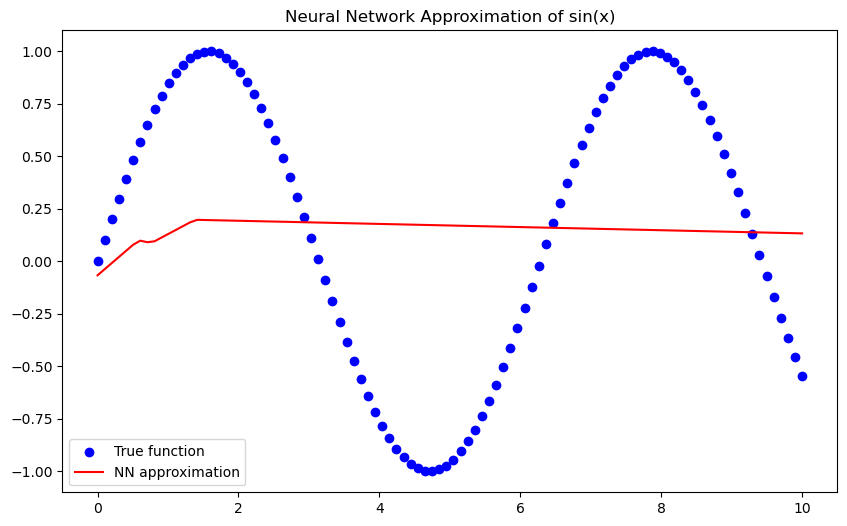

In [8]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.neural_network import MLPRegressor

# Generate data
X = np.linspace(0, 10, 100).reshape(-1, 1)
y = np.sin(X)

# Create and train the neural network
nn = MLPRegressor(hidden_layer_sizes=(10,), max_iter=1000)
nn.fit(X, y.ravel())

# Predict using the trained network
y_pred = nn.predict(X)

# Plot results
plt.figure(figsize=(10, 6))
plt.scatter(X, y, color='blue', label='True function')
plt.plot(X, y_pred, color='red', label='NN approximation')
plt.title('Neural Network Approximation of sin(x)')
plt.legend()
plt.show()

## Practical Limitations of the Universal Approximation Theorem

Although the Universal Approximation Theorem is theoretically powerful, it has several important practical limitations.

---

### 1. Network Size and Efficiency

The theorem guarantees the *existence* of a neural network that can approximate any continuous function, but it does not specify how large that network must be.

In practice:
- Some functions may require a very large number of neurons
- This leads to high computational cost and inefficiency

---

### 2. Overfitting

A neural network can learn the training data extremely well, sometimes too well.

This leads to **overfitting**, where:
- The model memorizes the training data
- But performs poorly on new, unseen data

Common solutions include:
- Dropout
- Early stopping
- Regularization techniques

---

### 3. Generalization

The theorem focuses on approximation over a given dataset, but does not guarantee good performance on new data.

In other words:
- A model may approximate the training function well
- But fail to generalize beyond it

To improve generalization:
- Use cross-validation
- Ensure diverse and representative data

---

### 4. Training Difficulties

The theorem states that a good approximation *exists*, but it does not explain how to find it efficiently.

In practice:
- Training relies on gradient-based optimization
- Optimization can be difficult due to:
  - Local minima
  - Saddle points
  - Slow convergence

This makes training deep neural networks a challenging task.

---

### Conclusion

The Universal Approximation Theorem ensures that neural networks are powerful in theory, but real-world performance depends on:
- Model design
- Training methods
- Data quality

### step 5: Limitations and Considerations

While the Universal Approximation Theorem guarantees the existence of a network that can approximate any continuous function, it doesn't provide information on how to find this network or how many neurons are needed. In practice, we often use multiple layers and optimization techniques to improve performance

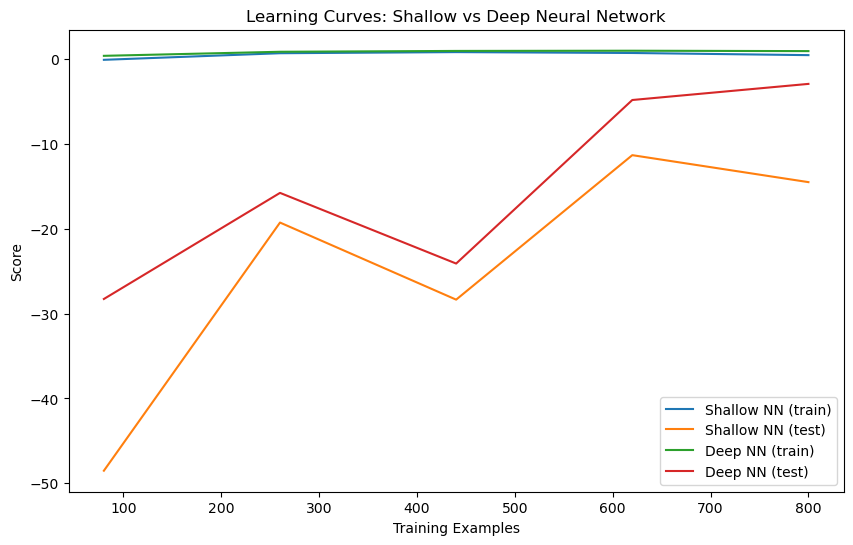

In [9]:
import numpy as np
from sklearn.neural_network import MLPRegressor
from sklearn.model_selection import learning_curve
import matplotlib.pyplot as plt

# Generate data
X = np.linspace(0, 10, 1000).reshape(-1, 1)
y = np.sin(X) + 0.1 * np.random.randn(1000, 1)

# Create MLPRegressor with different architectures
nn_shallow = MLPRegressor(hidden_layer_sizes=(10,), max_iter=1000)
nn_deep = MLPRegressor(hidden_layer_sizes=(10, 10, 10), max_iter=1000)

# Compute learning curves
train_sizes, train_scores_shallow, test_scores_shallow = learning_curve(nn_shallow, X, y.ravel(), cv=5)
train_sizes, train_scores_deep, test_scores_deep = learning_curve(nn_deep, X, y.ravel(), cv=5)

# Plot learning curves
plt.figure(figsize=(10, 6))
plt.plot(train_sizes, np.mean(train_scores_shallow, axis=1), label='Shallow NN (train)')
plt.plot(train_sizes, np.mean(test_scores_shallow, axis=1), label='Shallow NN (test)')
plt.plot(train_sizes, np.mean(train_scores_deep, axis=1), label='Deep NN (train)')
plt.plot(train_sizes, np.mean(test_scores_deep, axis=1), label='Deep NN (test)')
plt.title('Learning Curves: Shallow vs Deep Neural Network')
plt.xlabel('Training Examples')
plt.ylabel('Score')
plt.legend()
plt.show()

### Use example : Approximate a complex function

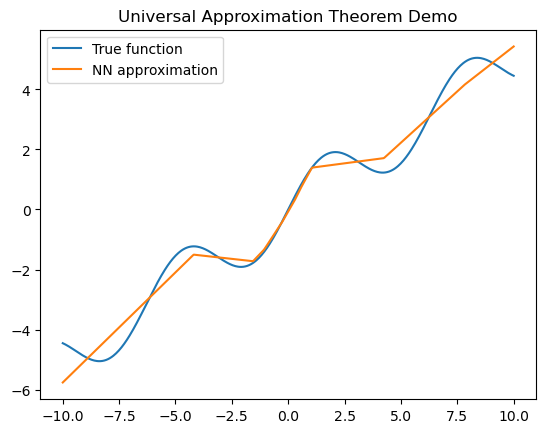

In [10]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.neural_network import MLPRegressor

# Generate data
X = np.linspace(-10, 10, 500).reshape(-1, 1)
y = np.sin(X).ravel() + 0.5 * X.ravel()

# Train neural network
model = MLPRegressor(hidden_layer_sizes=(50,), max_iter=2000)
model.fit(X, y)

# Predictions
X_test = np.linspace(-10, 10, 500).reshape(-1, 1)
y_pred = model.predict(X_test)

# Plot results
plt.plot(X, y, label="True function")
plt.plot(X_test, y_pred, label="NN approximation")
plt.legend()
plt.title("Universal Approximation Theorem Demo")
plt.show()

c:\ProgramData\anaconda3\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:1650: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


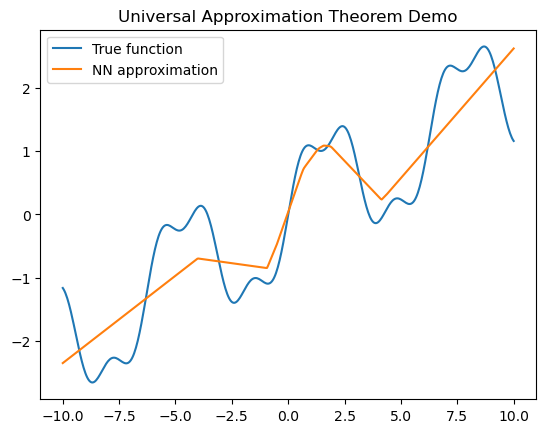

In [11]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.neural_network import MLPRegressor

# Generate data
X = np.linspace(-10, 10, 500).reshape(-1, 1)
y = np.sin(X) + 0.3*np.sin(3*X) + 0.2*X

# Train neural network
model = MLPRegressor(hidden_layer_sizes=(50,), max_iter=2000)
model.fit(X, y)

# Predictions
X_test = np.linspace(-10, 10, 500).reshape(-1, 1)
y_pred = model.predict(X_test)

# Plot results
plt.plot(X, y, label="True function")
plt.plot(X_test, y_pred, label="NN approximation")
plt.legend()
plt.title("Universal Approximation Theorem Demo")
plt.show()

### step8: Gradient Descent and Backpropagation

Neural networks are trained using gradient descent and backpropagation. These algorithms allow the network to learn from data by adjusting its weights and biases.

In [13]:
import numpy as np

def sigmoid(x):
    return 1 / (1 + np.exp(-x))

def sigmoid_derivative(x):
    return x * (1 - x)

class NeuralNetwork:
    def __init__(self, x, y):
        self.input = x
        self.weights1 = np.random.rand(self.input.shape[1], 4)
        self.weights2 = np.random.rand(4, 1)
        self.y = y
        self.output = np.zeros(self.y.shape)

    def feedforward(self):
        self.layer1 = sigmoid(np.dot(self.input, self.weights1))
        self.output = sigmoid(np.dot(self.layer1, self.weights2))

    def backprop(self):
        d_weights2 = np.dot(self.layer1.T, (2*(self.y - self.output) * sigmoid_derivative(self.output)))
        d_weights1 = np.dot(self.input.T,  (np.dot(2*(self.y - self.output) * sigmoid_derivative(self.output), self.weights2.T) * sigmoid_derivative(self.layer1)))

        self.weights1 += d_weights1
        self.weights2 += d_weights2

    def train(self, iterations):
        for _ in range(iterations):
            self.feedforward()
            self.backprop()

# Example usage
X = np.array([[0,0,1], [0,1,1], [1,0,1], [1,1,1]])
y = np.array([[0], [1], [1], [0]])
nn = NeuralNetwork(X, y)
nn.train(1500)

print(nn.output)

[[0.01927019]
 [0.97665609]
 [0.98102947]
 [0.02261073]]


### step9: Overfitting and Regularization

 as mentioned previously Overfitting occurs when a model learns the training data too well, including its noise, leading to poor generalization. Regularization techniques help prevent overfitting.

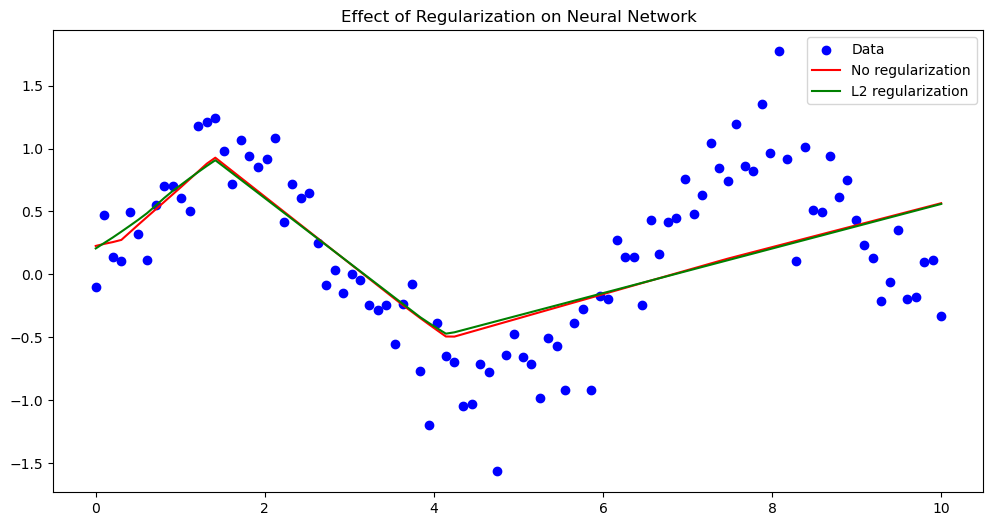

In [14]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.neural_network import MLPRegressor

# Generate noisy data
X = np.linspace(0, 10, 100).reshape(-1, 1)
y = np.sin(X) + 0.3 * np.random.randn(100, 1)

# Split data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Train models with different regularization
nn_no_reg = MLPRegressor(hidden_layer_sizes=(100,), alpha=0, max_iter=10000)
nn_l2 = MLPRegressor(hidden_layer_sizes=(100,), alpha=0.01, max_iter=10000)

nn_no_reg.fit(X_train, y_train.ravel())
nn_l2.fit(X_train, y_train.ravel())

# Plot results
plt.figure(figsize=(12, 6))
plt.scatter(X, y, color='blue', label='Data')
plt.plot(X, nn_no_reg.predict(X), color='red', label='No regularization')
plt.plot(X, nn_l2.predict(X), color='green', label='L2 regularization')
plt.title('Effect of Regularization on Neural Network')
plt.legend()
plt.show()

### step 10: Hyperparameter Tuning

Hyperparameters are configuration settings for the neural network that are not learned from data. Proper tuning of hyperparameters is crucial for optimal performance.



In [15]:
from sklearn.model_selection import GridSearchCV
from sklearn.neural_network import MLPClassifier
from sklearn.datasets import load_digits

# Load data
digits = load_digits()
X, y = digits.data, digits.target

# Define parameter grid
param_grid = {
    'hidden_layer_sizes': [(50,), (100,), (50, 50)],
    'activation': ['relu', 'tanh'],
    'alpha': [0.0001, 0.001, 0.01],
    'learning_rate': ['constant', 'adaptive'],
}

# Create MLPClassifier
mlp = MLPClassifier(max_iter=1000)

# Perform grid search
grid_search = GridSearchCV(mlp, param_grid, cv=3, n_jobs=-1)
grid_search.fit(X, y)

# Print best parameters and score
print("Best parameters:", grid_search.best_params_)
print("Best score:", grid_search.best_score_)

Best parameters: {'activation': 'tanh', 'alpha': 0.01, 'hidden_layer_sizes': (100,), 'learning_rate': 'constant'}
Best score: 0.9488035614913745
